# Эксперимент 14: MRL + No-Projection GAT

Анализ результатов для обоих loss'ов (BCE и NT-Xent) **одновременно** — без переключателя и перезапуска.

1. **Статистика MRL-графа** — что дала фильтрация (IDF + min-degree + per-cell)
2. **Сравнение с v3_unified** (exp 08) — на сколько меньше рёбер/токенов
3. **Кривые обучения** GAT без входных проекций — BCE и NT-Xent side-by-side
4. **Threshold-based evaluation** (F1/P/R + ROC-AUC/AP на val/test/cross-domain) — для обоих loss'ов
5. **Сравнение с v3 baseline** (exp 09/11) — v3 proj→128 vs v14 MRL no-proj 312, по обоим loss'ам
6. **Сводная таблица ablation** BCE vs NT-Xent
7. **t-SNE эмбеддингов** — side-by-side

Архитектура:
- `col_dim = row_dim = token_dim = hidden_dim = edge_dim = output_dim = 312`
- `use_input_projection=False` — учатся только GAT-слои + output_head
- column embeddings обрезаны 4096 → 312 через MRL (Matryoshka)

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../output")
MRL_DIR = DATA_DIR / "graphs" / "v14_mrl"
MRL_CROSS_DIR = DATA_DIR / "graphs" / "v14_mrl_cross"
V3_DIR = DATA_DIR / "graphs" / "v3_unified"

LOSSES = ("bce", "ntxent")
LOSS_COLORS = {"bce": "#FF9800", "ntxent": "#2196F3"}


def model_paths(loss: str) -> tuple[Path, Path, Path]:
    """Пути к (state_dict, config, history) для выбранного loss'а."""
    suffix = "_bce" if loss == "bce" else ""
    base = OUTPUT_DIR / f"v14_mrl_gat{suffix}_model"
    return (base.with_suffix(".pt"),
            base.with_suffix(".config.json"),
            base.with_suffix(".history.json"))


print("Доступность артефактов:")
for loss in LOSSES:
    mp, cp, hp = model_paths(loss)
    print(f"  [{loss:6s}] model={'✓' if mp.exists() else '✗'}  "
          f"cfg={'✓' if cp.exists() else '✗'}  "
          f"hist={'✓' if hp.exists() else '✗'}")

Доступность артефактов:
  [bce   ] model=✓  cfg=✓  hist=✓
  [ntxent] model=✓  cfg=✓  hist=✓


---
## 1. Статистика MRL-графа (exp 14 build)

In [2]:
with open(MRL_DIR / "stats.json") as f:
    stats = json.load(f)

print(f"Датасетов:        {stats['n_datasets']}")
print(f"Строк (row):      {stats['n_rows']:,}")
print(f"Токенов (token):  {stats['n_tokens']:,}")
print(f"Рёбер:            {stats['n_edges']:,}")
print(f"col_dim:          {stats['col_dim']} (MRL target_dim={stats['mrl_target_dim']})")
print(f"max_tokens/cell:  {stats['max_tokens_per_cell']}")
print(f"min_token_count:  {stats['min_token_count']}")
print()
print(f"Labeled pairs:    {stats['n_labeled']:,}")
print(f"  train:          {stats['n_train']:,} ({100*stats['n_train']/stats['n_labeled']:.1f}%)")
print(f"  val:            {stats['n_val']:,} ({100*stats['n_val']/stats['n_labeled']:.1f}%)")
print(f"  test:           {stats['n_test']:,} ({100*stats['n_test']/stats['n_labeled']:.1f}%)")

Датасетов:        21
Строк (row):      341,053
Токенов (token):  19,833
Рёбер:            9,280,687
col_dim:          312 (MRL target_dim=312)
max_tokens/cell:  8
min_token_count:  2

Labeled pairs:    6,797
  train:          4,758 (70.0%)
  val:            1,020 (15.0%)
  test:           1,019 (15.0%)


Этапы фильтрации токенов:
  Сырых токенов:               20,268
  Удалено IDF (df > 5%):   120 (0.6%)
  Удалено min-deg (df < 2):   87 (0.4%)
  Финальных токенов:           19,833

Этапы фильтрации рёбер:
  Сырых рёбер:                 24,306,686
  Удалено IDF:                 7,519,923 (30.9%)
  Удалено min-deg:             90 (0.0%)
  Удалено per-cell limit:      7,505,986 (30.9%)
  Финальных рёбер:             9,280,687 (38.2%)


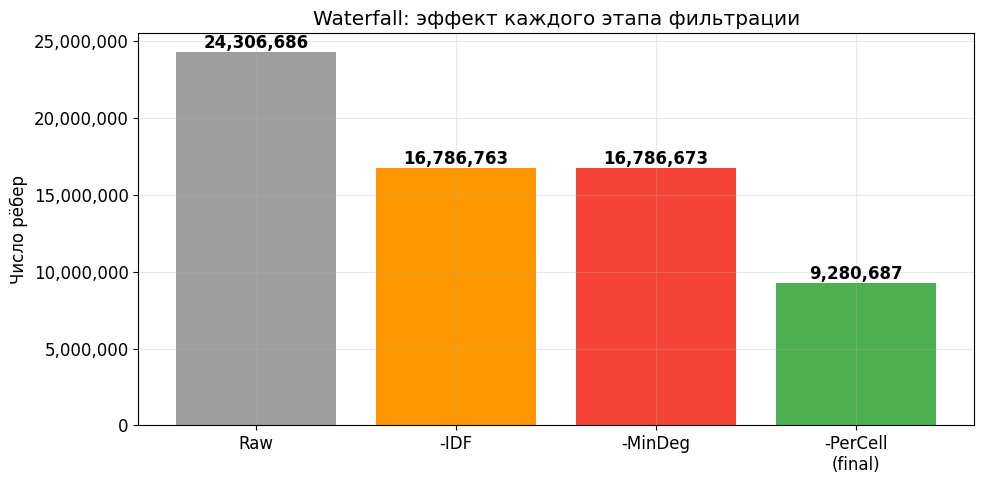

In [3]:
fs = stats["filter_stats"]
raw_e = fs["raw_edges"]
raw_t = fs["raw_tokens"]

print("Этапы фильтрации токенов:")
print(f"  Сырых токенов:               {raw_t:,}")
print(f"  Удалено IDF (df > {fs['idf_threshold']:.0%}):   {fs['tokens_removed_idf']:,} ({100*fs['tokens_removed_idf']/raw_t:.1f}%)")
print(f"  Удалено min-deg (df < {fs['min_token_count']}):   {fs['tokens_removed_mindeg']:,} ({100*fs['tokens_removed_mindeg']/raw_t:.1f}%)")
print(f"  Финальных токенов:           {fs['final_tokens']:,}")
print()
print("Этапы фильтрации рёбер:")
print(f"  Сырых рёбер:                 {raw_e:,}")
print(f"  Удалено IDF:                 {fs['edges_removed_idf']:,} ({100*fs['edges_removed_idf']/raw_e:.1f}%)")
print(f"  Удалено min-deg:             {fs['edges_removed_mindeg']:,} ({100*fs['edges_removed_mindeg']/raw_e:.1f}%)")
print(f"  Удалено per-cell limit:      {fs['edges_removed_cell_limit']:,} ({100*fs['edges_removed_cell_limit']/raw_e:.1f}%)")
print(f"  Финальных рёбер:             {fs['final_edges']:,} ({100*fs['final_edges']/raw_e:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
stages = ["Raw", "-IDF", "-MinDeg", "-PerCell\n(final)"]
values = [
    raw_e,
    raw_e - fs["edges_removed_idf"],
    raw_e - fs["edges_removed_idf"] - fs["edges_removed_mindeg"],
    fs["final_edges"],
]
colors = ["#9E9E9E", "#FF9800", "#F44336", "#4CAF50"]
bars = ax.bar(stages, values, color=colors)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{v:,}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Число рёбер")
ax.set_title("Waterfall: эффект каждого этапа фильтрации")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

---
## 2. Сравнение с v3_unified (baseline без MRL и min-degree)

Метрика                        v3_unified         v14_mrl      Ratio
----------------------------------------------------------------------
Строк                             341,053         341,053   100.00%
Токенов                            19,087          19,833   103.91%
Рёбер                           6,022,885       9,280,687   154.09%
col_dim (col emb)                    4096             312     7.62%


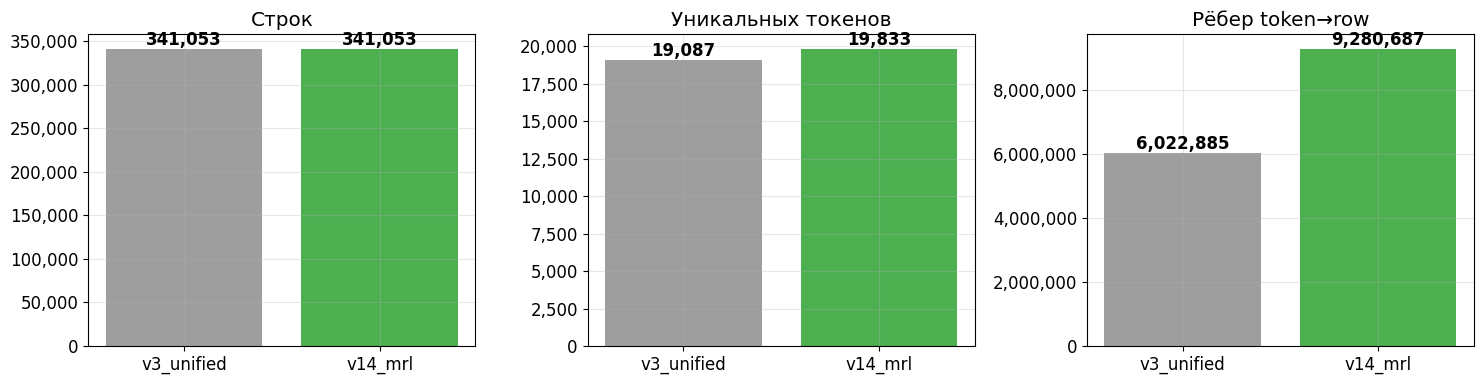

In [4]:
v3_stats_path = V3_DIR / "stats.json"
if v3_stats_path.exists():
    with open(v3_stats_path) as f:
        v3_stats = json.load(f)

    print(f"{'Метрика':<25} {'v3_unified':>15} {'v14_mrl':>15} {'Ratio':>10}")
    print("-" * 70)
    for key, label in [("n_rows", "Строк"), ("n_tokens", "Токенов"), ("n_edges", "Рёбер")]:
        v3, v14 = v3_stats[key], stats[key]
        print(f"{label:<25} {v3:>15,} {v14:>15,} {v14/v3:>9.2%}")
    print(f"{'col_dim (col emb)':<25} {'4096':>15} {stats['col_dim']:>15} {stats['col_dim']/4096:>9.2%}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key, title in zip(
        axes,
        ["n_rows", "n_tokens", "n_edges"],
        ["Строк", "Уникальных токенов", "Рёбер token→row"],
    ):
        vals = [v3_stats[key], stats[key]]
        bars = ax.bar(["v3_unified", "v14_mrl"], vals, color=["#9E9E9E", "#4CAF50"])
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{v:,}", ha="center", va="bottom", fontweight="bold")
        ax.set_title(title)
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    plt.show()
else:
    print("v3_unified/stats.json не найден — пропуск сравнения")

---
## 3. Кривые обучения GAT (no projection) — BCE и NT-Xent

Train/val loss и LR schedule для каждого loss'а side-by-side.

In [5]:
histories: dict[str, dict] = {}
for loss in LOSSES:
    _, _, hp = model_paths(loss)
    if hp.exists():
        with open(hp) as f:
            histories[loss] = json.load(f)

for loss, h in histories.items():
    epochs = list(range(1, len(h["train_loss"]) + 1))
    line = f"[{loss:6s}] эпох: {len(epochs):3d}  final_train={h['train_loss'][-1]:.4f}"
    if h.get("val_loss"):
        best = int(np.argmin(h["val_loss"]))
        line += f"  best_val={h['val_loss'][best]:.4f} (ep {best + 1})"
    if h.get("lr"):
        line += f"  final_lr={h['lr'][-1]:.2e}"
    print(line)

if not histories:
    print("Истории обучения не найдены.")

[bce   ] эпох: 1000  final_train=0.0142  best_val=0.3946 (ep 199)  final_lr=5.00e-04
[ntxent] эпох: 1000  final_train=0.1512  best_val=1.2359 (ep 934)  final_lr=5.00e-04


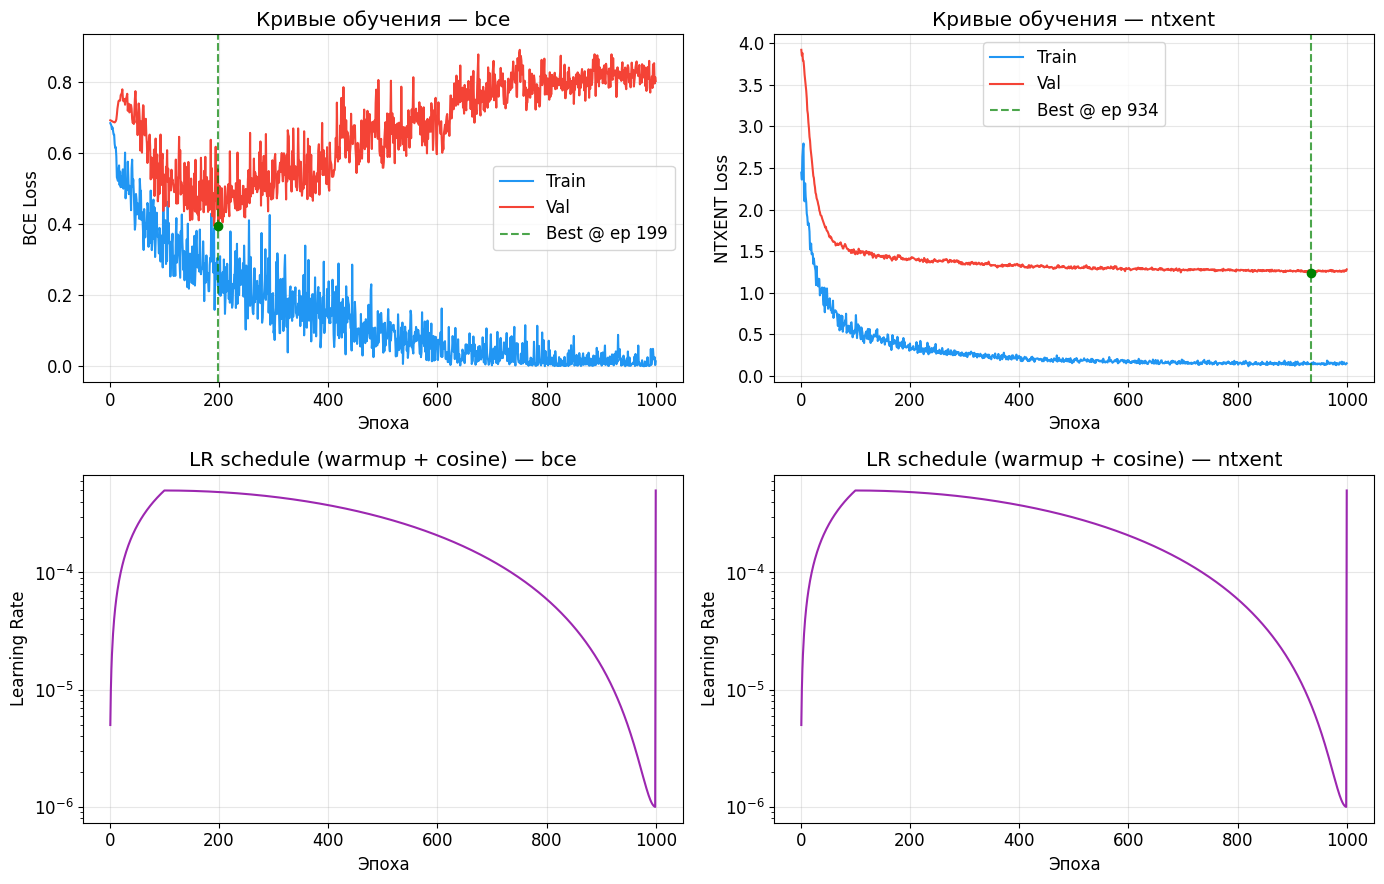

In [6]:
if histories:
    n = len(histories)
    fig, axes = plt.subplots(2, n, figsize=(7 * n, 9), squeeze=False)

    for i, (loss, h) in enumerate(histories.items()):
        epochs = list(range(1, len(h["train_loss"]) + 1))

        ax = axes[0, i]
        ax.plot(epochs, h["train_loss"], label="Train", color="#2196F3", linewidth=1.5)
        if h.get("val_loss"):
            v_ep = list(range(1, len(h["val_loss"]) + 1))
            ax.plot(v_ep, h["val_loss"], label="Val", color="#F44336", linewidth=1.5)
            best = int(np.argmin(h["val_loss"]))
            ax.axvline(best + 1, color="green", linestyle="--", alpha=0.7,
                       label=f"Best @ ep {best + 1}")
            ax.scatter([best + 1], [h["val_loss"][best]], color="green", zorder=5)
        ax.set_xlabel("Эпоха")
        ax.set_ylabel(f"{loss.upper()} Loss")
        ax.set_title(f"Кривые обучения — {loss}")
        ax.legend()

        ax = axes[1, i]
        if h.get("lr"):
            ax.plot(epochs, h["lr"], color="#9C27B0", linewidth=1.5)
            ax.set_xlabel("Эпоха")
            ax.set_ylabel("Learning Rate")
            ax.set_title(f"LR schedule (warmup + cosine) — {loss}")
            ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

---
## 4. Threshold-based evaluation (val → θ → test/cross) — для обоих loss'ов

Для каждого loss'а подбираем оптимальный θ на val и применяем его на test и cross-domain. Результаты кешируются в `output/v14_evaluation_results_{loss}.json`.

In [7]:
from table_unifier.evaluation.clustering import (
    evaluate_pairs_at_threshold,
    evaluate_pairs_auc,
    find_best_threshold,
)
from table_unifier.models.entity_resolution import EntityResolutionGAT, PairClassifier
from table_unifier.training.er_trainer import get_row_embeddings

device = "cuda" if torch.cuda.is_available() else "cpu"


def build_backbone(cfg: dict) -> EntityResolutionGAT:
    return EntityResolutionGAT(
        row_dim=cfg["row_dim"], token_dim=cfg["token_dim"], col_dim=cfg["col_dim"],
        hidden_dim=cfg["hidden_dim"], edge_dim=cfg["edge_dim"], output_dim=cfg["output_dim"],
        num_gnn_layers=cfg["num_gnn_layers"], num_heads=cfg["num_heads"],
        dropout=cfg["dropout"], attention_dropout=cfg["attention_dropout"],
        bidirectional=cfg["bidirectional"],
        use_input_projection=cfg["use_input_projection"],
    )


def load_backbone(model_path: Path, cfg: dict, loss: str) -> EntityResolutionGAT:
    """BCE сохраняется как PairClassifier, NT-Xent — как чистый backbone."""
    backbone = build_backbone(cfg)
    state = torch.load(model_path, map_location=device, weights_only=True)
    if loss == "bce":
        wrapper = PairClassifier(backbone, embedding_dim=cfg["output_dim"])
        wrapper.load_state_dict(state)
        wrapper.to(device).eval()
        return wrapper.backbone
    backbone.load_state_dict(state)
    backbone.to(device).eval()
    return backbone


def evaluate_loss(loss: str) -> dict:
    """Полная оценка модели на in-domain test + cross-domain."""
    mp, cp, _ = model_paths(loss)
    if not mp.exists():
        return {}
    with open(cp) as f:
        cfg = json.load(f)

    graph = torch.load(MRL_DIR / "graph.pt", weights_only=False)
    val_pairs = torch.load(MRL_DIR / "val_pairs.pt", weights_only=False)
    test_pairs = torch.load(MRL_DIR / "test_pairs.pt", weights_only=False)

    backbone = load_backbone(mp, cfg, loss)
    embeddings = get_row_embeddings(backbone, graph, device="cpu")

    threshold, _ = find_best_threshold(embeddings, val_pairs)
    out = {"threshold": threshold, "loss": loss}
    for split_name, pairs in [("val", val_pairs), ("test", test_pairs)]:
        m = evaluate_pairs_at_threshold(embeddings, pairs, threshold)
        m.update(evaluate_pairs_auc(embeddings, pairs))
        out[split_name] = m
    del graph, embeddings
    torch.cuda.empty_cache()

    cross = []
    if MRL_CROSS_DIR.exists():
        for ds_dir in sorted(MRL_CROSS_DIR.iterdir()):
            if not ds_dir.is_dir() or not (ds_dir / "graph.pt").exists():
                continue
            cg = torch.load(ds_dir / "graph.pt", weights_only=False)
            bb = load_backbone(mp, cfg, loss)
            emb = get_row_embeddings(bb, cg, device="cpu")
            cd = {"name": ds_dir.name}
            lp_path = ds_dir / "labeled_pairs.pt"
            if lp_path.exists():
                lp = torch.load(lp_path, weights_only=False)
                metrics = evaluate_pairs_at_threshold(emb, lp, threshold)
                metrics.update(evaluate_pairs_auc(emb, lp))
                cd.update(metrics)
            cross.append(cd)
            del cg, emb
            torch.cuda.empty_cache()
    out["cross_domain"] = cross
    return out


results_by_loss: dict[str, dict] = {}
for loss in LOSSES:
    cached = OUTPUT_DIR / f"v14_evaluation_results_{loss}.json"
    if cached.exists():
        with open(cached) as f:
            results_by_loss[loss] = json.load(f)
        print(f"  [{loss:6s}] загружено из кэша {cached.name}")
    else:
        print(f"  [{loss:6s}] оцениваю...")
        r = evaluate_loss(loss)
        if r:
            results_by_loss[loss] = r
            with open(cached, "w") as f:
                json.dump(r, f, ensure_ascii=False, indent=2)
        else:
            print(f"  [{loss:6s}] модель не найдена — пропуск")

for loss, res in results_by_loss.items():
    print(f"\n── [{loss}] θ = {res['threshold']:.4f} ──")
    for split_name in ("val", "test"):
        m = res[split_name]
        print(f"  {split_name:5s}: F1={m.get('f1', 0):.4f}  "
              f"P={m.get('precision', 0):.4f}  R={m.get('recall', 0):.4f}  "
              f"AUC={m.get('roc_auc', 0):.4f}  AP={m.get('avg_precision', 0):.4f}")
    for cd in res.get("cross_domain", []):
        print(f"  cross/{cd['name']:15s}  F1={cd.get('f1', 0):.4f}  "
              f"P={cd.get('precision', 0):.4f}  R={cd.get('recall', 0):.4f}  "
              f"AUC={cd.get('roc_auc', 0):.4f}")

  [bce   ] загружено из кэша v14_evaluation_results_bce.json
  [ntxent] загружено из кэша v14_evaluation_results_ntxent.json

── [bce] θ = 0.4972 ──
  val  : F1=0.7851  P=0.7205  R=0.8625  AUC=0.8642  AP=0.8789
  test : F1=0.7766  P=0.7150  R=0.8497  AUC=0.8710  AP=0.8808
  cross/anime            F1=0.5581  P=0.9836  R=0.3896  AUC=0.9460
  cross/citations        F1=0.0000  P=0.0000  R=0.0000  AUC=0.5586
  cross/electronics      F1=0.6818  P=0.8571  R=0.5660  AUC=0.9156

── [ntxent] θ = 0.6389 ──
  val  : F1=0.7877  P=0.7395  R=0.8426  AUC=0.8617  AP=0.8700
  test : F1=0.7822  P=0.7566  R=0.8096  AUC=0.8672  AP=0.8660
  cross/anime            F1=0.2967  P=0.9643  R=0.1753  AUC=0.9686
  cross/citations        F1=0.0000  P=0.0000  R=0.0000  AUC=0.5837
  cross/electronics      F1=0.2903  P=1.0000  R=0.1698  AUC=0.9417


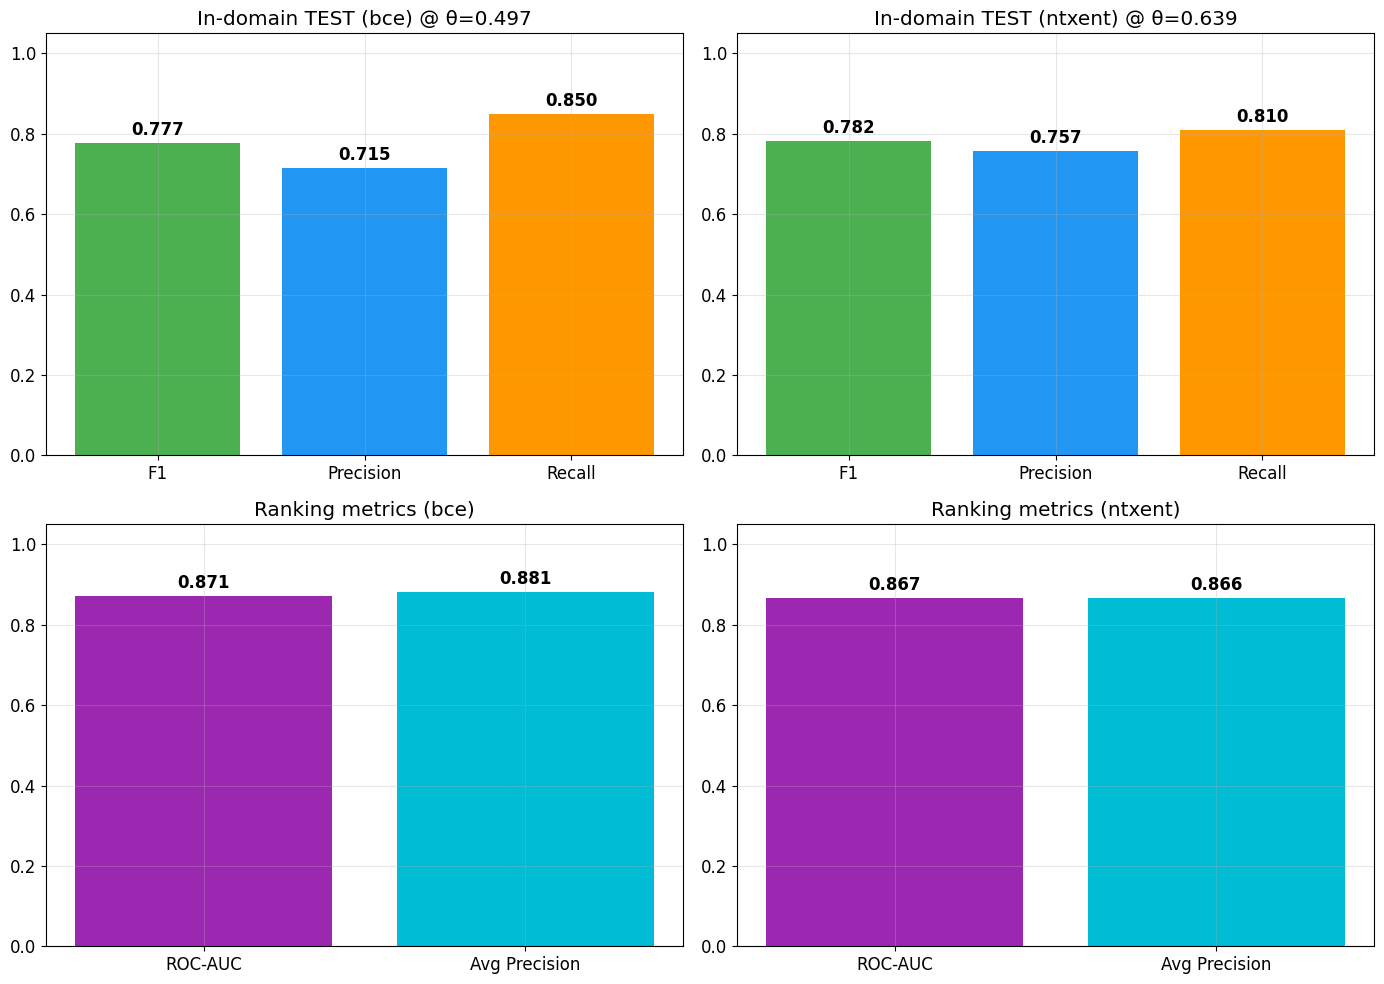

In [8]:
# In-domain TEST bars — оба loss'а side-by-side
if results_by_loss:
    n = len(results_by_loss)
    fig, axes = plt.subplots(2, n, figsize=(7 * n, 10), squeeze=False)

    for i, (loss, res) in enumerate(results_by_loss.items()):
        t = res["test"]
        theta = res["threshold"]

        ax = axes[0, i]
        names = ["F1", "Precision", "Recall"]
        vals = [t.get("f1", 0), t.get("precision", 0), t.get("recall", 0)]
        bars = ax.bar(names, vals, color=["#4CAF50", "#2196F3", "#FF9800"])
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.set_title(f"In-domain TEST ({loss}) @ θ={theta:.3f}")

        ax = axes[1, i]
        names = ["ROC-AUC", "Avg Precision"]
        vals = [t.get("roc_auc", 0), t.get("avg_precision", 0)]
        bars = ax.bar(names, vals, color=["#9C27B0", "#00BCD4"])
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.set_title(f"Ranking metrics ({loss})")

    plt.tight_layout()
    plt.show()

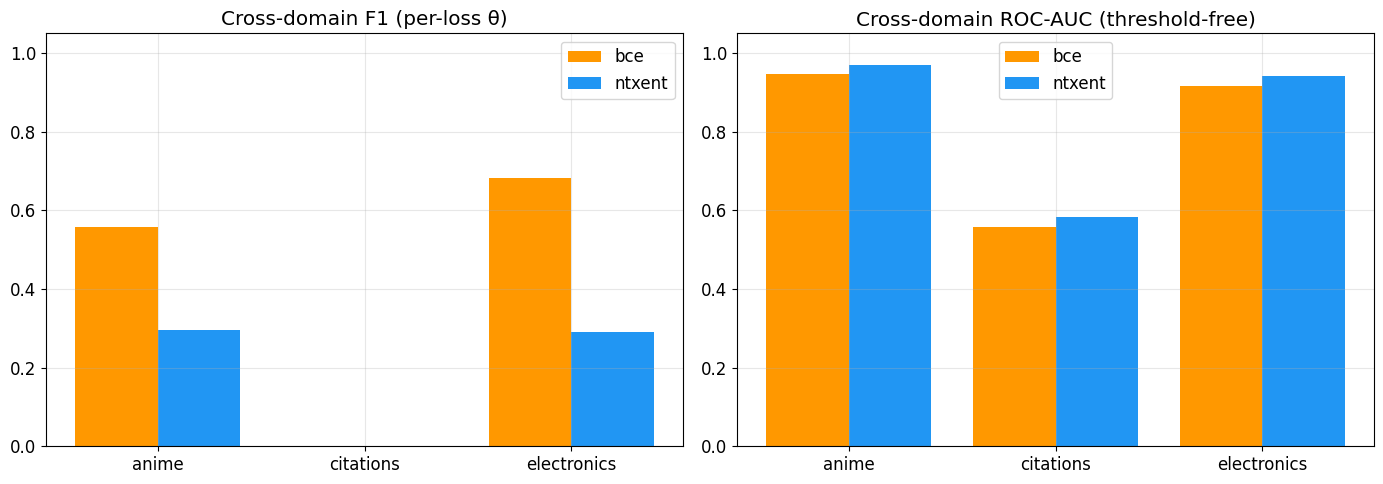

In [9]:
# Cross-domain — сгруппированные столбцы BCE vs NT-Xent
all_cross_names = sorted({
    r["name"]
    for res in results_by_loss.values()
    for r in res.get("cross_domain", [])
})

if all_cross_names and results_by_loss:
    cd_per_loss = {
        loss: {r["name"]: r for r in res.get("cross_domain", [])}
        for loss, res in results_by_loss.items()
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(all_cross_names))
    n_loss = len(results_by_loss)
    w = 0.8 / max(n_loss, 1)

    ax = axes[0]
    for i, loss in enumerate(results_by_loss.keys()):
        f1s = [cd_per_loss[loss].get(n, {}).get("f1", 0) for n in all_cross_names]
        offset = (i - (n_loss - 1) / 2) * w
        ax.bar(x + offset, f1s, w, label=loss, color=LOSS_COLORS.get(loss))
    ax.set_xticks(x); ax.set_xticklabels(all_cross_names)
    ax.set_ylim(0, 1.05); ax.legend()
    ax.set_title("Cross-domain F1 (per-loss θ)")

    ax = axes[1]
    for i, loss in enumerate(results_by_loss.keys()):
        aucs = [cd_per_loss[loss].get(n, {}).get("roc_auc", 0) for n in all_cross_names]
        offset = (i - (n_loss - 1) / 2) * w
        ax.bar(x + offset, aucs, w, label=loss, color=LOSS_COLORS.get(loss))
    ax.set_xticks(x); ax.set_xticklabels(all_cross_names)
    ax.set_ylim(0, 1.05); ax.legend()
    ax.set_title("Cross-domain ROC-AUC (threshold-free)")

    plt.tight_layout()
    plt.show()

---
## 5. Сравнение с v3 baseline (proj→128 vs MRL no-proj 312)

Для каждого loss'а: v3 GAT с проекциями vs v14 MRL без проекций — in-domain таблица + cross-domain графики.

In [10]:
import pandas as pd


def v3_results_path(loss: str) -> Path:
    suffix = "_bce" if loss == "bce" else ""
    return OUTPUT_DIR / f"v3_evaluation_results{suffix}.json"


v3_results_by_loss: dict[str, dict] = {}
for loss in LOSSES:
    p = v3_results_path(loss)
    if p.exists():
        with open(p) as f:
            v3_results_by_loss[loss] = json.load(f)

# In-domain TEST — единая таблица для обоих loss'ов
rows = []
for loss in LOSSES:
    for label, res in [
        (f"v3 GAT {loss} (proj→128)", v3_results_by_loss.get(loss)),
        (f"v14 GAT {loss} (MRL no-proj 312)", results_by_loss.get(loss)),
    ]:
        if not res:
            continue
        t = res.get("test", {})
        rows.append({
            "Model": label,
            "Threshold": res.get("threshold"),
            "F1": t.get("f1"), "Precision": t.get("precision"),
            "Recall": t.get("recall"), "ROC-AUC": t.get("roc_auc"),
            "AP": t.get("avg_precision"),
        })

if rows:
    print("In-domain TEST:")
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print("Нет результатов для сравнения.")

In-domain TEST:
                           Model  Threshold       F1  Precision   Recall  ROC-AUC       AP
           v3 GAT bce (proj→128)   0.534113 0.760591   0.748062 0.773547 0.834315 0.843440
   v14 GAT bce (MRL no-proj 312)   0.497221 0.776557   0.715008 0.849699 0.870957 0.880806
        v3 GAT ntxent (proj→128)   0.768300 0.843621   0.866808 0.821643 0.921932 0.924905
v14 GAT ntxent (MRL no-proj 312)   0.638888 0.782188   0.756554 0.809619 0.867154 0.865962


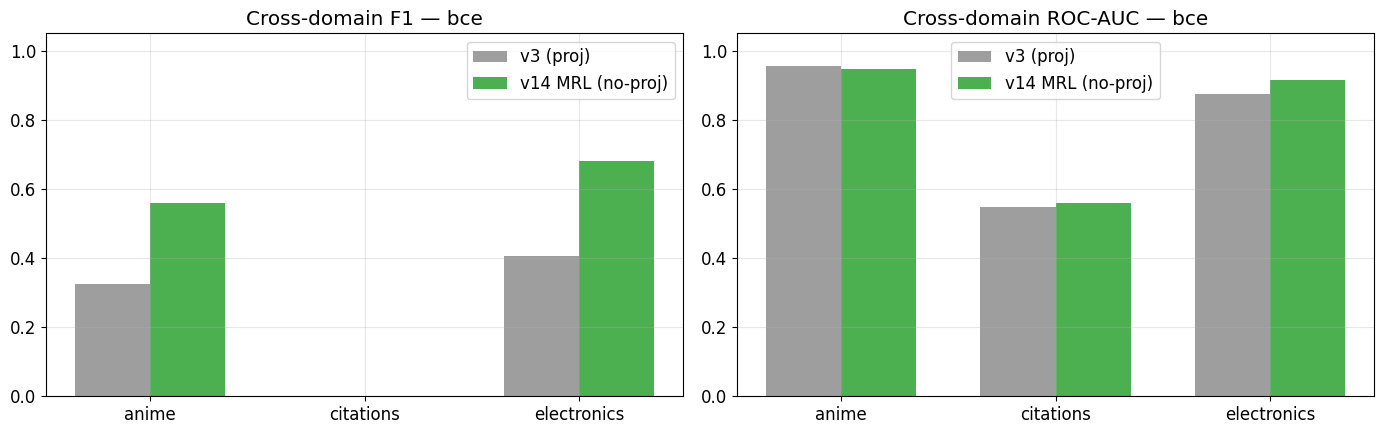

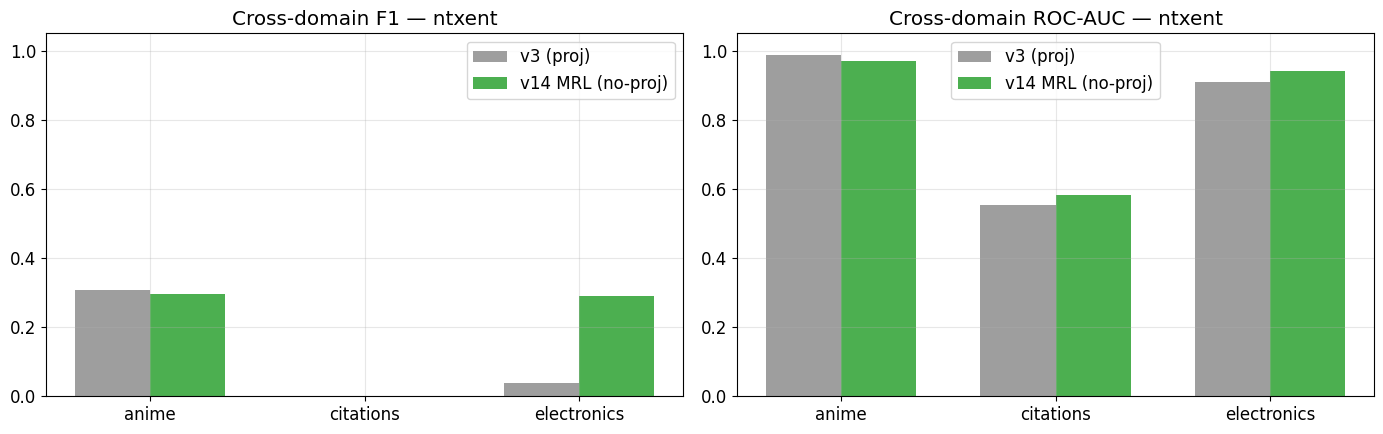

In [11]:
# Cross-domain: для каждого loss'а v3 vs v14 MRL side-by-side
for loss in LOSSES:
    v3_res = v3_results_by_loss.get(loss)
    v14_res = results_by_loss.get(loss)
    if not v3_res or not v14_res:
        continue

    cross_v3 = {r["name"]: r for r in v3_res.get("cross_domain", [])}
    cross_v14 = {r["name"]: r for r in v14_res.get("cross_domain", [])}
    names = sorted(set(cross_v3) | set(cross_v14))
    if not names:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    x = np.arange(len(names))
    w = 0.35

    ax = axes[0]
    v3_f1 = [cross_v3.get(n, {}).get("f1", 0) for n in names]
    v14_f1 = [cross_v14.get(n, {}).get("f1", 0) for n in names]
    ax.bar(x - w / 2, v3_f1, w, label="v3 (proj)", color="#9E9E9E")
    ax.bar(x + w / 2, v14_f1, w, label="v14 MRL (no-proj)", color="#4CAF50")
    ax.set_xticks(x); ax.set_xticklabels(names)
    ax.set_ylim(0, 1.05); ax.legend()
    ax.set_title(f"Cross-domain F1 — {loss}")

    ax = axes[1]
    v3_auc = [cross_v3.get(n, {}).get("roc_auc", 0) for n in names]
    v14_auc = [cross_v14.get(n, {}).get("roc_auc", 0) for n in names]
    ax.bar(x - w / 2, v3_auc, w, label="v3 (proj)", color="#9E9E9E")
    ax.bar(x + w / 2, v14_auc, w, label="v14 MRL (no-proj)", color="#4CAF50")
    ax.set_xticks(x); ax.set_xticklabels(names)
    ax.set_ylim(0, 1.05); ax.legend()
    ax.set_title(f"Cross-domain ROC-AUC — {loss}")

    plt.tight_layout()
    plt.show()

---
## 6. Сводная таблица ablation: BCE vs NT-Xent (v14 MRL)

Те же графики кривых обучения и cross-domain метрик уже показаны в секциях 3 и 4. Здесь — единая таблица всех ключевых чисел для экспорта в отчёт.

In [12]:
if results_by_loss:
    rows = []
    for loss, res in results_by_loss.items():
        t = res.get("test", {})
        v = res.get("val", {})
        rows.append({
            "Loss": loss,
            "Threshold": res.get("threshold"),
            "Val F1": v.get("f1"),
            "Test F1": t.get("f1"),
            "Test P": t.get("precision"),
            "Test R": t.get("recall"),
            "Test ROC-AUC": t.get("roc_auc"),
            "Test AP": t.get("avg_precision"),
        })
    df_summary = pd.DataFrame(rows)
    print("v14 MRL — In-domain сводка:")
    print(df_summary.to_string(index=False))

    # Cross-domain — длинная таблица (loss × dataset × metric)
    cd_rows = []
    for loss, res in results_by_loss.items():
        for cd in res.get("cross_domain", []):
            cd_rows.append({
                "Loss": loss,
                "Dataset": cd["name"],
                "F1": cd.get("f1"),
                "P": cd.get("precision"),
                "R": cd.get("recall"),
                "ROC-AUC": cd.get("roc_auc"),
                "AP": cd.get("avg_precision"),
            })
    if cd_rows:
        print("\nv14 MRL — Cross-domain сводка:")
        print(pd.DataFrame(cd_rows).to_string(index=False))

v14 MRL — In-domain сводка:
  Loss  Threshold   Val F1  Test F1   Test P   Test R  Test ROC-AUC  Test AP
   bce   0.497221 0.785131 0.776557 0.715008 0.849699      0.870957 0.880806
ntxent   0.638888 0.787709 0.782188 0.756554 0.809619      0.867154 0.865962

v14 MRL — Cross-domain сводка:
  Loss     Dataset       F1        P        R  ROC-AUC       AP
   bce       anime 0.558140 0.983607 0.389610 0.945974 0.922636
   bce   citations 0.000000 0.000000 0.000000 0.558562 0.289458
   bce electronics 0.681818 0.857143 0.566038 0.915578 0.747820
ntxent       anime 0.296703 0.964286 0.175325 0.968571 0.954708
ntxent   citations 0.000000 0.000000 0.000000 0.583672 0.278844
ntxent electronics 0.290323 1.000000 0.169811 0.941703 0.756583


---
## 7. t-SNE эмбеддингов (cross-domain) — BCE и NT-Xent

Эмбеддинги строк для каждого cross-domain датасета, одновременно для обоих loss'ов. Колонки — датасеты, строки — loss'ы.

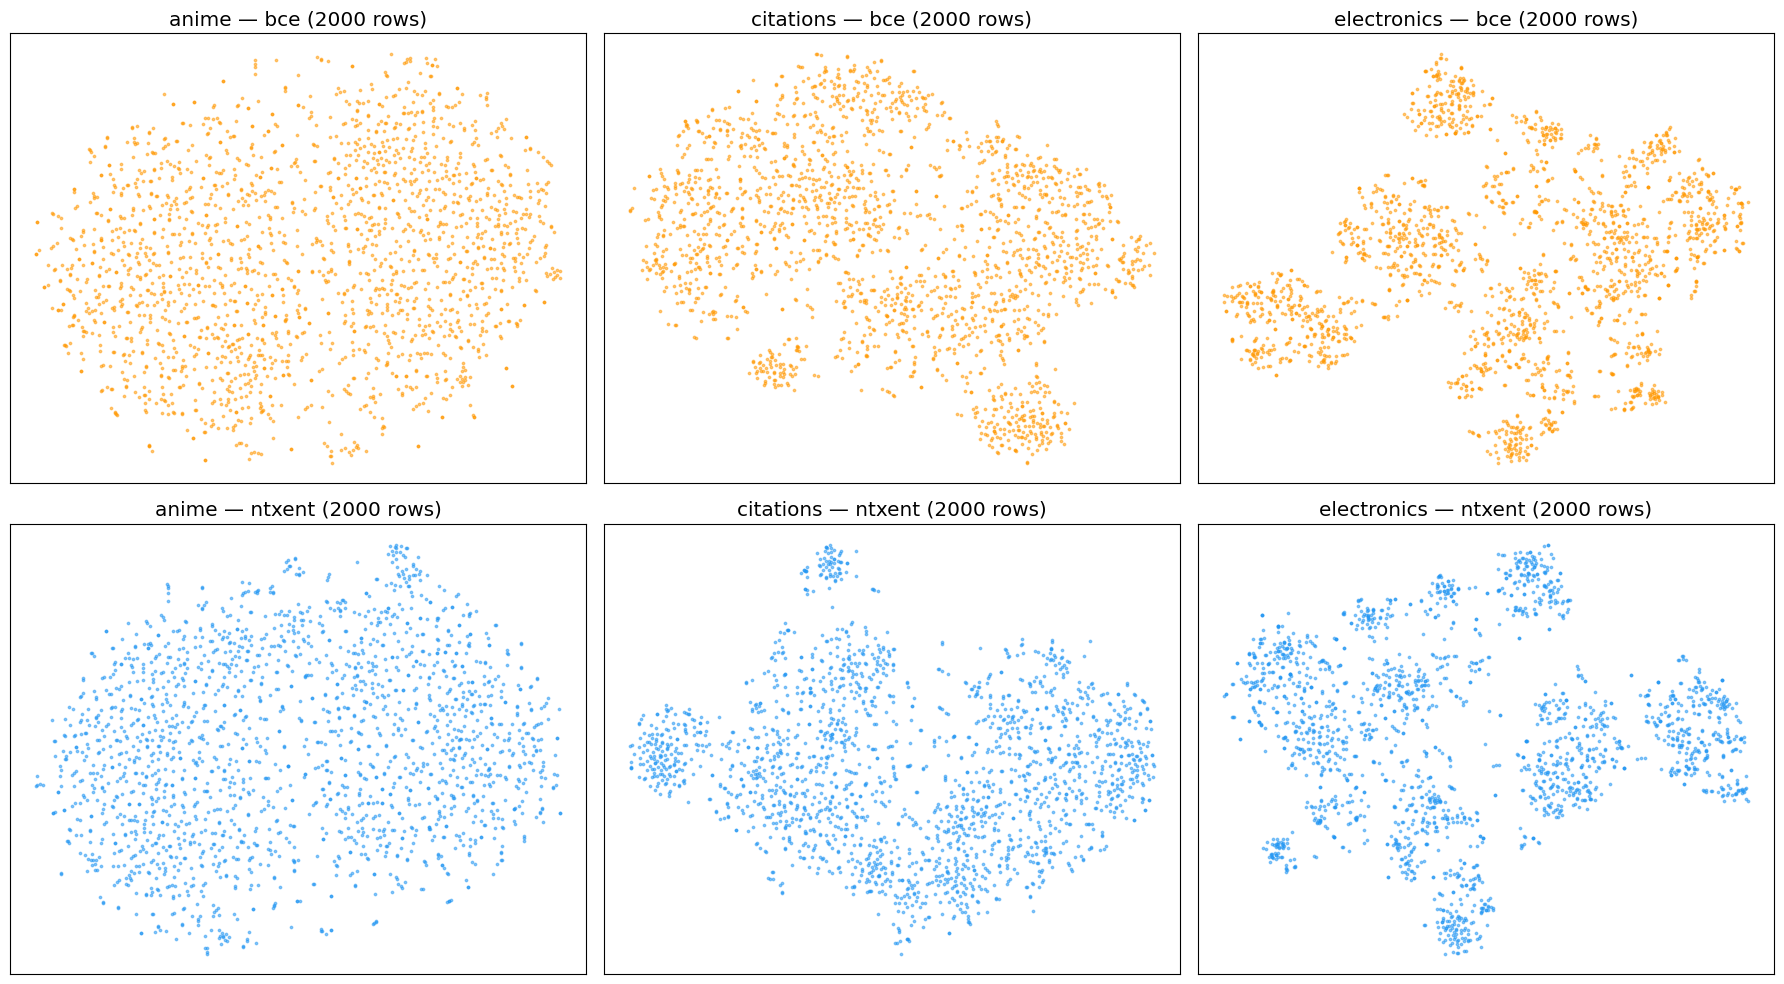

In [13]:
from sklearn.manifold import TSNE

if MRL_CROSS_DIR.exists() and results_by_loss:
    cross_dirs = sorted([d for d in MRL_CROSS_DIR.iterdir()
                         if d.is_dir() and (d / "graph.pt").exists()])

    if cross_dirs:
        n_loss = len(results_by_loss)
        n_ds = len(cross_dirs)
        fig, axes = plt.subplots(n_loss, n_ds,
                                 figsize=(6 * n_ds, 5 * n_loss),
                                 squeeze=False)

        # Кешируем cfg'и по loss, чтобы не читать файл многократно
        cfgs: dict[str, dict] = {}
        for loss in results_by_loss:
            _, cp, _ = model_paths(loss)
            with open(cp) as f:
                cfgs[loss] = json.load(f)

        for col, ds_dir in enumerate(cross_dirs):
            cg = torch.load(ds_dir / "graph.pt", weights_only=False)
            for row, (loss, _) in enumerate(results_by_loss.items()):
                mp, _, _ = model_paths(loss)
                bb = load_backbone(mp, cfgs[loss], loss)
                emb = get_row_embeddings(bb, cg, device="cpu").numpy()

                n_sub = min(2000, len(emb))
                idx = np.random.RandomState(42).choice(len(emb), n_sub, replace=False)
                emb_sub = emb[idx]

                tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=42)
                coords = tsne.fit_transform(emb_sub)

                ax = axes[row, col]
                ax.scatter(coords[:, 0], coords[:, 1], s=3, alpha=0.5,
                           color=LOSS_COLORS.get(loss))
                ax.set_title(f"{ds_dir.name} — {loss} ({n_sub} rows)")
                ax.set_xticks([]); ax.set_yticks([])

                del emb
                torch.cuda.empty_cache()
            del cg
            torch.cuda.empty_cache()

        plt.tight_layout()
        plt.show()